In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

In [2]:
data_path = '/product_marketing/06_customer_segmentation_demographics/netflix_users.csv'
netflix_user = pd.read_csv('netflix_users.csv')

In [3]:
netflix_user.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [4]:
netflix_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


In [5]:
netflix_user.describe()

,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


In [6]:
# unique values in categorical columns
categorical_cols = ['Country', 'Subscription_Type', 'Favorite_Genre']
for col in categorical_cols:
    print(f"Unique values in {col}: {netflix_user[col].unique()}")

   

Unique values in Country: ['France' 'USA' 'UK' 'Canada' 'Mexico' 'Japan' 'Australia' 'Germany'
 'Brazil' 'India']
Unique values in Subscription_Type: ['Premium' 'Basic' 'Standard']
Unique values in Favorite_Genre: ['Drama' 'Sci-Fi' 'Comedy' 'Documentary' 'Romance' 'Action' 'Horror']


In [7]:
# print columns
print(netflix_user.columns)

Index(['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type',
       'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login'],
      dtype='object')


In [8]:
X = netflix_user[['Age', 'Country', 'Subscription_Type', 'Favorite_Genre']]

In [9]:
encoder = OneHotEncoder(sparse_output=True)
X_cat = encoder.fit_transform(X[['Country', 'Subscription_Type', 'Favorite_Genre']])

In [10]:
scaler = StandardScaler()
X_num = scaler.fit_transform(X[['Age']])

In [11]:
X_cat
print(X_cat.shape)

(25000, 20)


In [12]:
X_num
print(X_num.shape)

(25000, 1)


In [13]:
#Convert X_cat to dense
X_cat_dense = X_cat.toarray()
X_final = np.hstack([X_num, X_cat_dense])

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
netflix_user['cluster'] = kmeans.fit_predict(X_final)

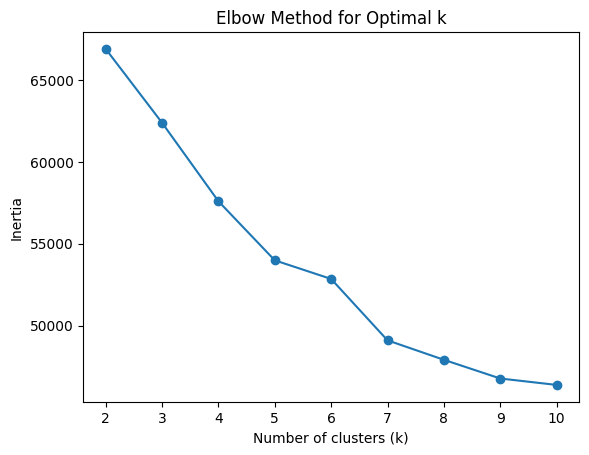

In [46]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

inertias = []
K = range(2, 11)

for k in K:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1024
    )
    model.fit(X_final)
    inertias.append(model.inertia_)

# Plot elbow
plt.figure()
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

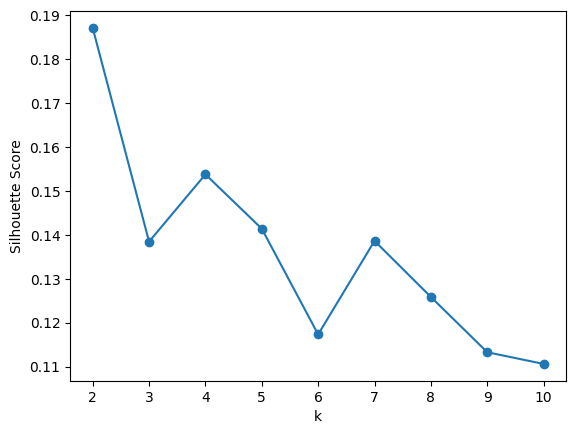

In [53]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    model = MiniBatchKMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_final)  # dense required
    score = silhouette_score(X_final, labels)
    scores.append(score)

plt.figure()
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()


In [15]:
kmeans = KMeans(n_clusters=7, random_state=42)
netflix_user['cluster'] = kmeans.fit_predict(X_final)

In [16]:
print(netflix_user['cluster'].value_counts())

cluster
3    4216
0    4186
6    4136
1    4106
5    2857
4    2756
2    2743
Name: count, dtype: int64


In [17]:
netflix_user.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,cluster
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,0
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,0
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,2
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,0
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,1


# Đặc trưng của từng nhóm cluster

In [19]:
netflix_cluster = netflix_user.copy()

In [20]:
netflix_cluster.groupby('cluster').size()

cluster
0    4186
1    4106
2    2743
3    4216
4    2756
5    2857
6    4136
dtype: int64

In [22]:
# Đặc trưng Numeric (age, watch_time)
numeric_profile = netflix_cluster.groupby('cluster').agg(
    avg_age=('Age', 'mean'),
    median_age=('Age', 'median'),
    avg_watch_time=('Watch_Time_Hours', 'mean'),
    p75_watch_time=('Watch_Time_Hours', lambda x: np.percentile(x, 75))
).round(2)

numeric_profile

,avg_age,median_age,avg_watch_time,p75_watch_time
cluster,,,,
0,29.68,30.0,499.63,746.51
1,63.60,64.0,494.75,747.20
2,69.27,70.0,502.95,746.06
3,63.32,63.0,503.18,745.40
4,46.77,47.0,504.37,746.52
5,23.94,24.0,501.72,748.05
6,29.61,29.0,499.13,739.88


In [26]:
# Đặc trưng của Categorical (Country, Subscription_Type, Favorite_Genre)
subscription_dist = (
    netflix_cluster.groupby('cluster')['Subscription_Type'].value_counts().rename("ratio").reset_index()
)

subscription_dist

,cluster,Subscription_Type,ratio
0,0,Premium,4186
1,1,Standard,4106
2,2,Basic,2743
3,3,Premium,4216
4,4,Basic,2756
5,5,Basic,2857
6,6,Standard,4136


In [32]:
top_genre = (
    netflix_cluster
    .groupby("cluster")["Favorite_Genre"]
    .value_counts()
    .groupby(level=0)
    .head(3)
    .reset_index(name="count")
)

top_genre


,cluster,Favorite_Genre,count
0,0,Horror,650
1,0,Sci-Fi,608
2,0,Documentary,598
3,1,Action,635
4,1,Drama,614
5,1,Documentary,613
6,2,Documentary,419
7,2,Comedy,414
8,2,Action,394
9,3,Horror,617


In [28]:
# Phân tích đặc trưng Recency (ngày đăng nhập gần nhất)

netflix_cluster["Last_Login"] = pd.to_datetime(netflix_cluster["Last_Login"])

netflix_cluster["days_since_last_login"] = (
    pd.Timestamp("now") - netflix_cluster["Last_Login"]
).dt.days

recency_profile = netflix_cluster.groupby("cluster").agg(
    avg_days_since_login=("days_since_last_login", "mean"),
    median_days_since_login=("days_since_last_login", "median")
).round(1)

recency_profile


,avg_days_since_login,median_days_since_login
cluster,,
0,513.3,513.0
1,510.2,506.0
2,509.5,509.0
3,516.6,518.0
4,513.0,512.0
5,516.2,517.0
6,511.0,510.0


In [33]:
cluster_summary = netflix_cluster.groupby("cluster").agg(
    size=("User_ID", "count"),
    avg_age=("Age", "mean"),
    avg_watch_time=("Watch_Time_Hours", "mean"),
    top_country=("Country", lambda x: x.mode()[0]),
    top_subscription=("Subscription_Type", lambda x: x.mode()[0]),
    top_genre=("Favorite_Genre", lambda x: x.mode()[0]),
    avg_recency=("days_since_last_login", "mean")
).round(1)

cluster_summary


,size,avg_age,avg_watch_time,top_country,top_subscription,top_genre,avg_recency
cluster,,,,,,,
0,4186,29.7,499.6,USA,Premium,Horror,513.3
1,4106,63.6,494.7,UK,Standard,Action,510.2
2,2743,69.3,502.9,UK,Basic,Documentary,509.5
3,4216,63.3,503.2,Australia,Premium,Horror,516.6
4,2756,46.8,504.4,Mexico,Basic,Romance,513.0
5,2857,23.9,501.7,France,Basic,Action,516.2
6,4136,29.6,499.1,USA,Standard,Romance,511.0
